In [67]:
using LowLevelFEM

In [68]:
line_mesh(order=3)

In [69]:

mat = Material("body")
U = Field([mat], type=:VectorField, dim=2, fieldName=:u, rhsName=:f)
Φ = Field([mat], type=:ScalarField, dim=2, fieldName=:φ, rhsName=:m, reducedOrder=true);

In [70]:
t = tangentVector(U, "body")
tx, ty, tz = t[1], t[2], t[3]

nx = -ty
ny = tx
nz = 0;

In [71]:
# ------------------------------------------------------------------
# Generalized Timoshenko beam strain
#
# ε = tᵀ ∇u t
# γ = nᵀ ∇u t - φ
# κ = ∇φ ⋅ t
# ------------------------------------------------------------------

Au = [
    tx*tx tx*ty tx*ty ty*ty
    nx*tx nx*ty ny*tx ny*ty
    0 0 0 0]

Aφ = [
    0 0
    0 0
    tx ty]

Gφ = [0; -1; 0;;]

Bu = Au ⋅ Grad(U)

Bφ = Aφ ⋅ Grad(Φ) + Gφ ⋅ Φ;

In [72]:
b = 30
h = 5
E = mat.E
G = mat.μ
Iz = b * h^3 / 12
κ = 4 / 5
A = b * h;

In [73]:
D = [
    E*A 0 0
    0 κ*G*A 0
    0 0 E*Iz]

3×3 Matrix{Float64}:
 3.0e7  0.0        0.0
 0.0    9.23077e6  0.0
 0.0    0.0        6.25e7

In [74]:
B = Bu + Bφ
K = ∫(B' ⋅ D ⋅ B, Γ="body");

In [75]:
supp_u = BoundaryCondition("left", field=U, ux=0, uy=0)
supp_φ = BoundaryCondition("left", field=Φ, φ=0)

BoundaryCondition("left", Problem("line_mesh", :ScalarField, 2, 1, Material[Material("body", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0)], 1.0, 31, LowLevelFEM.Geometry("", "", 0, 0, nothing, nothing, nothing, nothing), :φ, :m, true), Dict{Symbol, Union{Function, Number, ScalarField}}(:φ => 0))

In [76]:
loadf = LoadCondition("body", fy=0)
loadF = LoadCondition("right", fy=0)
loadM = LoadCondition("right", m=1)

fu = loadVector(U, [loadf, loadF])
fφ = loadVector(Φ, [loadM])

F = SystemVector([fu, fφ]);

In [77]:
u, φ = solveField(K, F, support=[supp_u, supp_φ]);

In [78]:
showDoFResults(fu, name="force")
showDoFResults(u, name="u", factor=20, visible=true);

In [79]:
n = VectorField([nx, ny, 0]);

In [80]:
u = expandTo3D(u)
φ = nodesToElements(φ)

g = ∇(u)

ε = t ⋅ (g * t)
γ = n ⋅ (g * t) - φ

κb = -∇(φ) ⋅ t

N = E * A * ε
T = κ * G * A * γ
Mh = E * Iz * κb;

In [81]:
N0, plotN = plotOnBeam("body", N, name="N graph", plot=true)
T0, plotT = plotOnBeam("body", T, name="T graph", plot=true)
Mh0, plotMh = plotOnBeam("body", Mh, name="Mh graph", plot=true)

(4, ([0.0, 0.03333333333333333, 0.06666666666666667, 0.1, 0.1, 0.13333333333333333, 0.16666666666666666, 0.2, 0.2, 0.23333333333333336  …  0.7666666666666667, 0.8, 0.8, 0.8333333333333334, 0.8666666666666667, 0.9, 0.9, 0.9333333333333333, 0.9666666666666667, 1.0], [-1.0000000000002343, -1.000000000000234, -1.0000000000002334, -1.0000000000002323, -1.0000000000002374, -1.0000000000002331, -1.0000000000002307, -1.0000000000002307, -1.000000000000234, -1.0000000000002256  …  -1.0000000000001033, -1.0000000000001017, -1.0000000000001148, -1.0000000000000817, -1.000000000000062, -1.000000000000062, -1.0000000000000289, -1.0000000000000322, -1.0000000000000107, -0.9999999999999692]))

In [82]:
using Plots

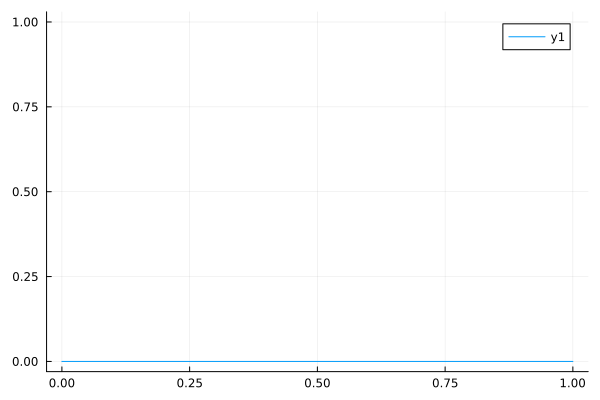

In [83]:
plot(plotN)

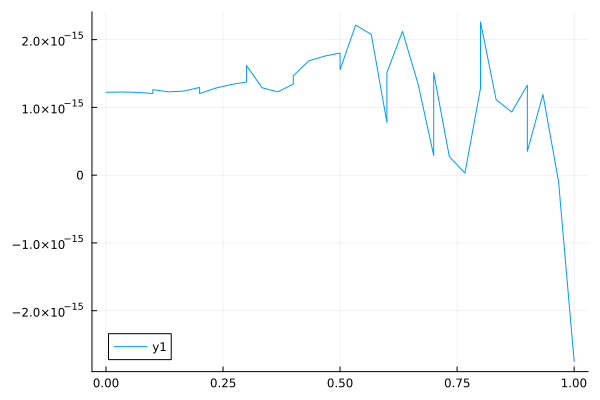

In [84]:
plot(plotT)

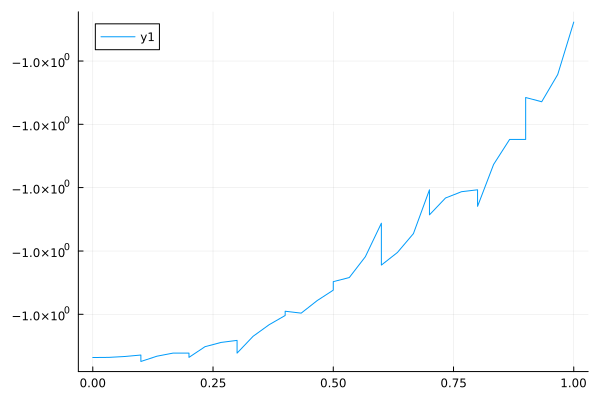

In [85]:
plot(plotMh)

In [86]:
openPostProcessor()